# Linear Regression via Gradient Descent

**Model**

$$f_{w,b}(x_i) = w x_i + b$$

**Cost function**

$$J(w,b) = \frac{1}{2m}\sum_{i=1}^{m}\left(f_{w,b}(x_i) - y_i\right)^2$$

**Gradients**

$$\frac{\partial J}{\partial w} = \frac{1}{m}\sum_{i=1}^{m}\left(f_{w,b}(x_i) - y_i\right)x_i
\qquad
\frac{\partial J}{\partial b} = \frac{1}{m}\sum_{i=1}^{m}\left(f_{w,b}(x_i) - y_i\right)$$

**Update rule (simultaneous)**

$$w = w - \alpha \frac{\partial J}{\partial w} \qquad b = b - \alpha \frac{\partial J}{\partial b}$$


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

## Cost function

Just $J(w,b)$ from above, vectorized over all $m$ examples.

In [ ]:
def compute_cost(x, y, w, b):
    """J(w, b): mean squared error over all m examples."""
    m = x.shape[0]
    f_wb = w * x + b
    cost = np.sum((f_wb - y) ** 2) / (2 * m)
    return cost

## Gradients

`error = f_wb(x_i) - y_i` for every example at once.

- `dw` multiplies by `x_i` (from $\frac{d}{dw}(w x_i) = x_i$)
- `db` doesn't (from $\frac{d}{db} y_i = 0$, only the $f_{w,b}$ term survives)

In [ ]:
def compute_gradient(x, y, w, b):
    """Returns dJ/dw and dJ/db at the current w, b."""
    m = x.shape[0]
    f_wb = w * x + b
    error = f_wb - y          # (f_wb(x_i) - y_i) for every i, vectorized

    dw = np.sum(error * x) / m
    db = np.sum(error) / m
    return dw, db

## Gradient descent loop

Repeatedly applies the update rule, tracking cost so we can check convergence.

In [ ]:
def gradient_descent(x, y, w_init, b_init, alpha, num_iters, print_every=100):
    """
    Runs gradient descent to fit w, b.
    Returns final w, b, and the cost history (useful for checking convergence).
    """
    w, b = w_init, b_init
    cost_history = []

    for i in range(num_iters):
        dw, db = compute_gradient(x, y, w, b)

        # simultaneous update
        w = w - alpha * dw
        b = b - alpha * db

        cost_history.append(compute_cost(x, y, w, b))

        if i % print_every == 0:
            print(f"iter {i:5d}: cost {cost_history[-1]:10.4f}  w {w:.4f}  b {b:.4f}")

    return w, b, cost_history

## Toy dataset

Roughly $y = 2x + 1$ with a bit of Gaussian noise, so we know the target answer.

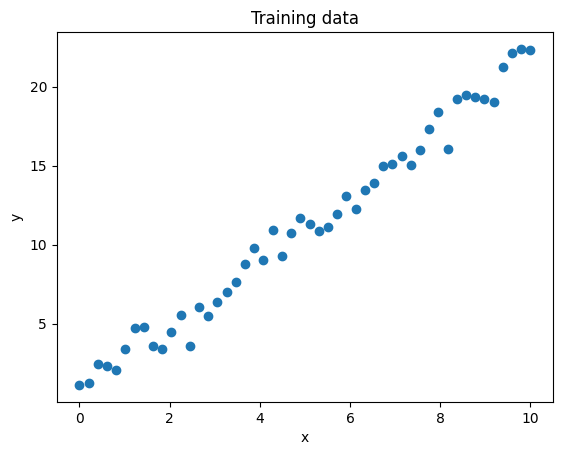

In [ ]:
rng = np.random.default_rng(0)
x_train = np.linspace(0, 10, 50)
y_train = 2 * x_train + 1 + rng.normal(0, 1, size=x_train.shape)

plt.scatter(x_train, y_train)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Training data")
plt.show()

## Run gradient descent

In [ ]:
w_final, b_final, J_hist = gradient_descent(
    x_train, y_train,
    w_init=0.0, b_init=0.0,
    alpha=0.01, num_iters=1000
)

print(f"\nFinal parameters: w = {w_final:.4f}, b = {b_final:.4f}")
print("(Target was approximately w = 2, b = 1)")

iter     0: cost    35.3434  w 0.7400  b 0.1113
iter   100: cost     0.3607  w 2.1424  b 0.3728
iter   200: cost     0.3591  w 2.1365  b 0.4120
iter   300: cost     0.3582  w 2.1319  b 0.4425
iter   400: cost     0.3576  w 2.1284  b 0.4662
iter   500: cost     0.3572  w 2.1256  b 0.4847
iter   600: cost     0.3570  w 2.1235  b 0.4990
iter   700: cost     0.3569  w 2.1218  b 0.5101
iter   800: cost     0.3568  w 2.1205  b 0.5187
iter   900: cost     0.3568  w 2.1195  b 0.5254

Final parameters: w = 2.1188, b = 0.5306
(Target was approximately w = 2, b = 1)


## Check the results

Cost should decrease and flatten out (convergence), and the fitted line should track the data.

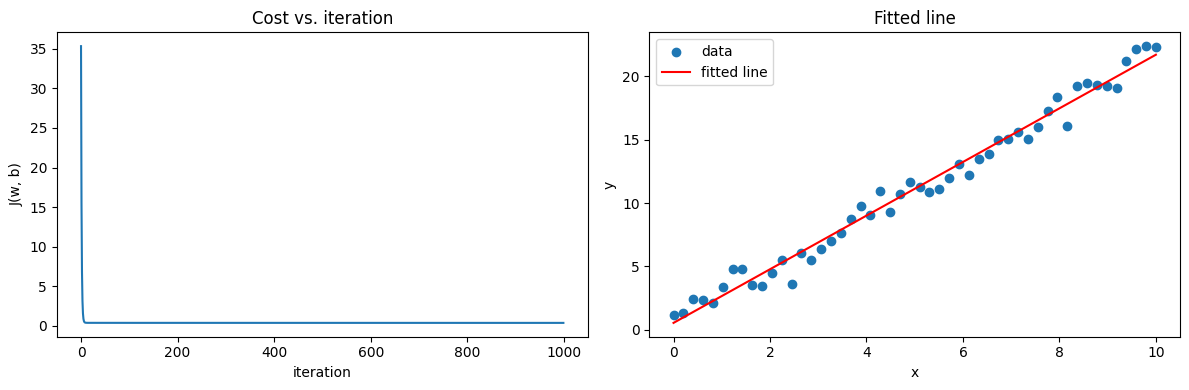

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(J_hist)
axes[0].set_xlabel("iteration")
axes[0].set_ylabel("J(w, b)")
axes[0].set_title("Cost vs. iteration")

axes[1].scatter(x_train, y_train, label="data")
axes[1].plot(x_train, w_final * x_train + b_final, color="red", label="fitted line")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
axes[1].set_title("Fitted line")
axes[1].legend()

plt.tight_layout()
plt.show()